**Prak-3 Implement Clustering using DBSCAN**

---



1. Menginstal pustaka pembantu (kagglehub) untuk mengunduh dataset secara otomatis tanpa perlu mengunggah file CSV secara manual. Selanjutnya, kita melakukan import semua pustaka (library) yang diperlukan.

In [1]:
!pip install kagglehub[pandas-datasets] -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter

sns.set_theme(style="whitegrid")
print("Sedang mengunduh dataset dari Kaggle...")
file_path = "Country-data.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "rohan0301/unsupervised-learning-on-country-data",
    file_path,
)

print("Berhasil memuat data dari 167 negara!")

display(df[['country', 'child_mort', 'gdpp']].head())

Sedang mengunduh dataset dari Kaggle...


/tmp/ipykernel_10946/659966857.py:15: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'unsupervised-learning-on-country-data' dataset.
Berhasil memuat data dari 167 negara!


,country,child_mort,gdpp
0,Afghanistan,90.2,553
1,Albania,16.6,4090
2,Algeria,27.3,4460
3,Angola,119.0,3530
4,Antigua and Barbuda,10.3,12200


2. Bisa kita lihat hasil di atas ini, nilai gdpp berada di angka ribuan (bahkan puluhan ribu), sedangkan child_mort hanya puluhan. Jika kita langsung menjalankan DBSCAN, jarak antara
titik-titik data akan didominasi oleh gdpp, dan nyawa anak-anak (child_mort) seolah diabaikan oleh komputer.

- Algoritma DBSCAN sangat sensitif terhadap skala data karena ia bekerja dengan menghitung jarak (Euclidean Distance) antar titik.

  Maka dari itu di bawah ini kita lakukan standarisasi.

In [2]:
from sklearn.preprocessing import StandardScaler

X = df[['child_mort', 'gdpp']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Contoh 5 data pertama setelah distandarisasi: ")
print(X_scaled[:5])

Contoh 5 data pertama setelah distandarisasi: 
[[ 1.29153238 -0.67917961]
 [-0.5389489  -0.48562324]
 [-0.27283273 -0.46537561]
 [ 2.00780766 -0.51626829]
 [-0.69563412 -0.04181713]]


3. Sebagai Data Scientist, sebelum kita menyuruh mesin mencari cluster, kita harus melihat sendiri bentuk datanya menggunakan mata kita. Buat Scatter Plot (Grafik Titik) dari data yang sudah distandarisasi tadi. Sumbu X adalah tingkat kematian anak, dan Sumbu Y adalah pendapatan per kapita. Dari grafik ini, kita bisa mereka-reka apakah ada kelompok-kelompok natural atau titik-titik anomali (outlier) yang letaknya jauh dari kerumunan.

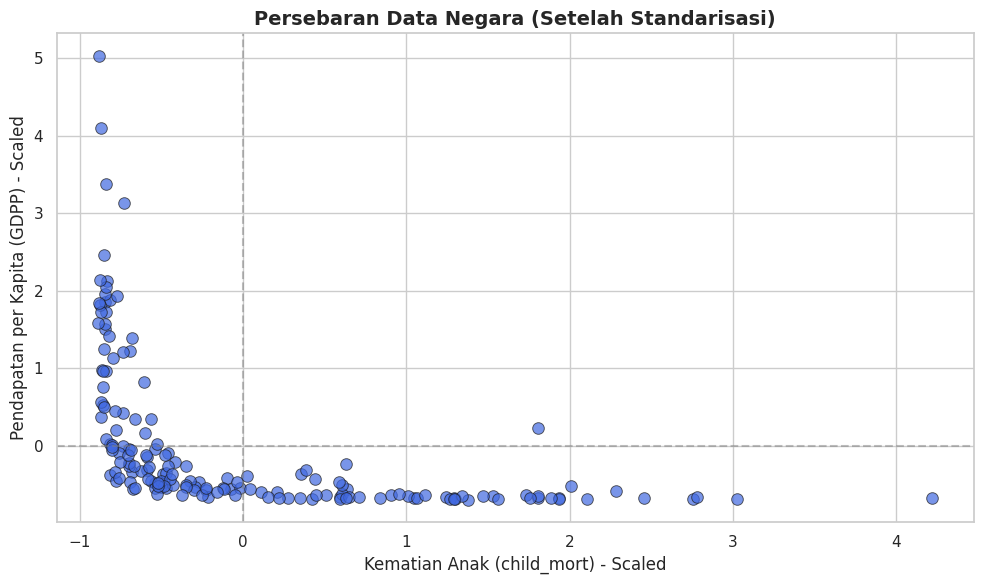

In [3]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x=X_scaled[:, 0],
    y=X_scaled[:, 1],
    color='royalblue',
    s=70,
    alpha=0.7,
    edgecolor='k'
)

plt.title("Persebaran Data Negara (Setelah Standarisasi)", fontsize=14, fontweight='bold')
plt.xlabel("Kematian Anak (child_mort) - Scaled", fontsize=12)
plt.ylabel("Pendapatan per Kapita (GDPP) - Scaled", fontsize=12)

plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

4. kita akan mengaplikasikan algoritma DBSCAN menggunakan data yang sudah distandarisasi. Pada percobaan pertama ini, kita akan menggunakan parameter standar:

- eps = 0.5: Jarak radius maksimal untuk mencari tetangga adalah 0.5 standar deviasi.
- min_samples = 5: Syarat minimal untuk membentuk sebuah kelompok (klaster) adalah 5 negara yang saling berdekatan.

  Jika ada negara yang posisinya sangat jauh sendirian dan tidak memiliki 5 tetangga di sekitarnya, maka negara itu akan dilabeli dengan angka -1 (Noise / Anomali).

In [6]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.5, min_samples=5)

labels = dbscan.fit_predict(X_scaled)

df['Cluster'] = labels

print("DBSCAN berhasil dijalankan!")
print("\nRingkasan Hasil Pembagian Klaster (CLuster ID : Jumlah Negara): ")
print(df['Cluster'].value_counts().sort_index())

DBSCAN berhasil dijalankan!

Ringkasan Hasil Pembagian Klaster (CLuster ID : Jumlah Negara): 
Cluster
-1      6
 0    161
Name: count, dtype: int64


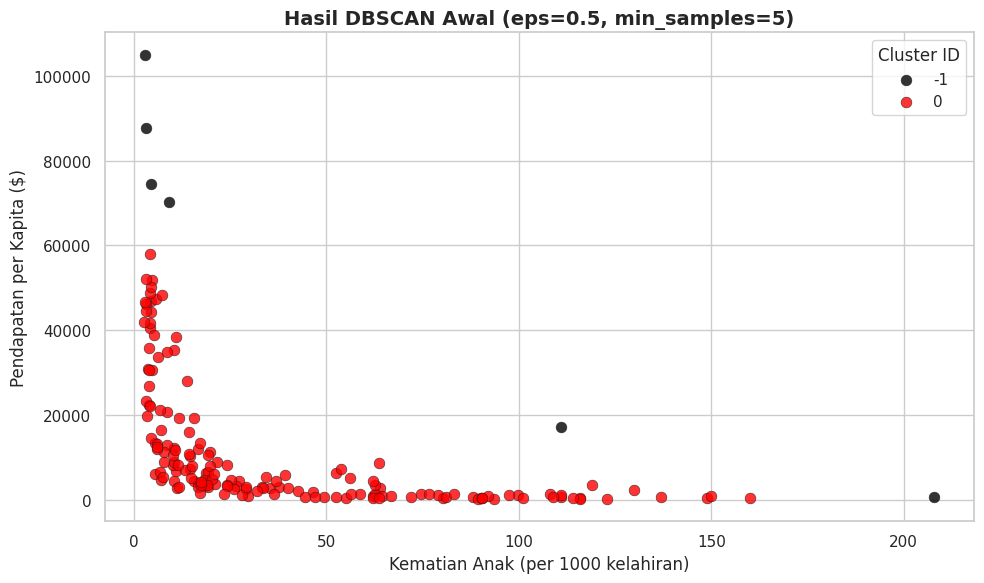

In [7]:
plt.figure(figsize=(10, 6))

unique_labels = sorted(df['Cluster'].unique())

colors = {-1: 'black', 0: 'red'}

for label in unique_labels:
    mask = df['Cluster'] == label
    color = colors.get(label, 'blue')
    plt.scatter(
        df.loc[mask, 'child_mort'],
        df.loc[mask, 'gdpp'],
        c=color,
        s=60,
        alpha=0.8,
        edgecolors='k',
        linewidths=0.4,
        label=str(label)
    )

plt.title("Hasil DBSCAN Awal (eps=0.5, min_samples=5)", fontsize=14, fontweight='bold')
plt.xlabel("Kematian Anak (per 1000 kelahiran)", fontsize=12)
plt.ylabel("Pendapatan per Kapita ($)", fontsize=12)
plt.legend(title="Cluster ID", loc="upper right")
plt.tight_layout()
plt.show()

5. Hasil percobaan eps=0.5 ternyata menyatukan 161 negara menjadi 1 kelompok besar. Ini menandakan radius terlalu longgar.

    Bagaimana cara mencari angka yang pas? Dalam algoritma DBSCAN, kita menggunakan K-Distance Graph (mirip dengan Elbow Method pada K-Means).

- Kita menetapkan target min_samples = 4 (karena kita punya 2 kolom data, aturannya adalah minPts > D + 1, namun 4 adalah standar yang sering dipakai).

- Kita akan menghitung jarak dari setiap negara ke tetangga terdekat ke-4 nya.

- Kita urutkan jarak tersebut dan kita buat grafiknya. Titik di mana grafik melonjak tajam (membentuk siku/lutut) adalah batas optimal sebelum data berubah menjadi Noise.

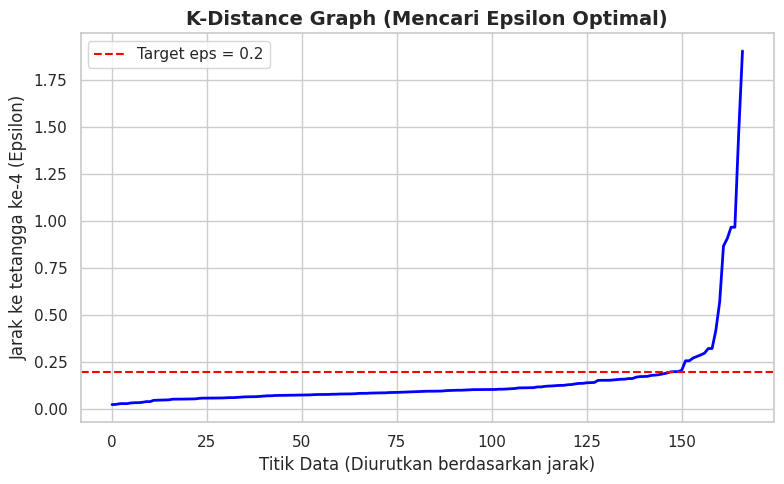

In [8]:
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=4)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)

distances = np.sort(distances[:, 3], axis=0)

plt.figure(figsize=(8, 5))
plt.plot(distances, color='blue', linewidth=2)

plt.title("K-Distance Graph (Mencari Epsilon Optimal)", fontsize=14, fontweight='bold')
plt.xlabel("Titik Data (Diurutkan berdasarkan jarak)", fontsize=12)
plt.ylabel("Jarak ke tetangga ke-4 (Epsilon)", fontsize=12)

plt.axhline(y=0.2, color='red', linestyle='--', label='Target eps = 0.2')

plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

6. Berdasarkan kode sebelumnya epsilon yang optimal, kita tuning DBSCAN kita dengan min sample 4 dan epsilon 0,2.

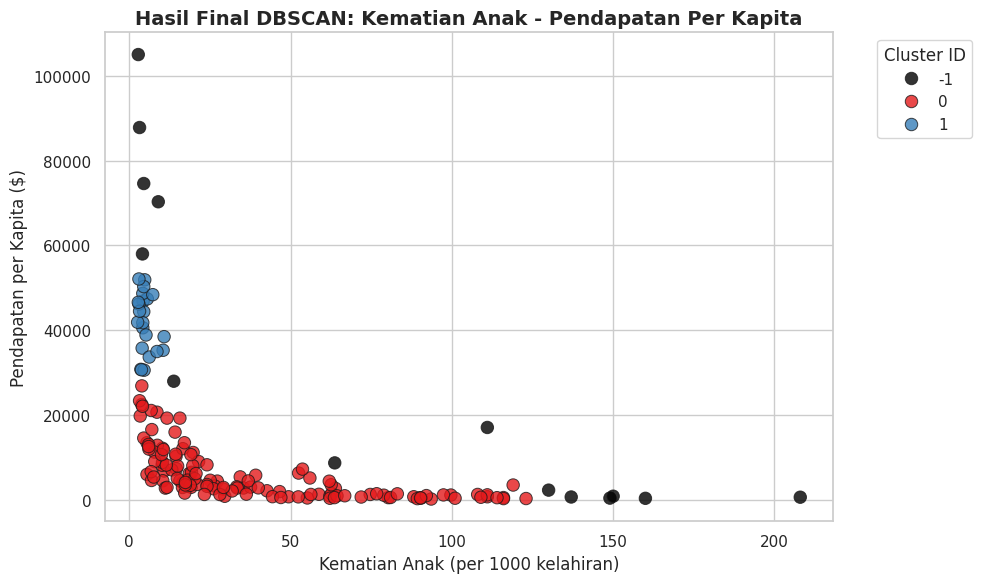

DISTRIBUSI NEGARA PADA KLASTER FINAL: 
Cluster_Final
-1     14
 0    130
 1     23
Name: count, dtype: int64


In [10]:
dbscan_final = DBSCAN(eps=0.2, min_samples=4)
df['Cluster_Final'] = dbscan_final.fit_predict(X_scaled)

plt.figure(figsize=(10, 6))
unique_clusters_final = len(np.unique(df['Cluster_Final']))
palette_final = sns.color_palette("Set1", unique_clusters_final - 1)
palette_final.insert(0, (0.0, 0.0, 0.0))

sns.scatterplot(
    x=df['child_mort'],
    y=df['gdpp'],
    hue=df['Cluster_Final'],
    palette=palette_final,
    s=80,
    alpha=0.8,
    edgecolor='k'
)

plt.title("Hasil Final DBSCAN: Kematian Anak - Pendapatan Per Kapita", fontsize=14, fontweight='bold')
plt.xlabel("Kematian Anak (per 1000 kelahiran)", fontsize=12)
plt.ylabel("Pendapatan per Kapita ($)", fontsize=12)
plt.legend(title="Cluster ID", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print("DISTRIBUSI NEGARA PADA KLASTER FINAL: ")
print(df['Cluster_Final'].value_counts().sort_index())

7. **Kesimpulan dan Hasil Analisis DBSCAN**

   Dari analisis DBSCAN yang telah dilakukan pada data `child_mort` (kematian anak) dan `gdpp` (pendapatan per kapita) dari berbagai negara, kita dapat menarik beberapa kesimpulan:

   *   **Pentingnya Standardisasi Data**: Sebelum menerapkan DBSCAN, data `child_mort` dan `gdpp` perlu distandardisasi. Ini karena perbedaan skala nilai yang ekstrem antara kedua variabel dapat mendominasi perhitungan jarak, sehingga `gdpp` akan memiliki pengaruh yang jauh lebih besar dibandingkan `child_mort` jika tidak distandardisasi.

   *   **Percobaan Awal DBSCAN (eps=0.5, min_samples=5)**: Dengan parameter awal ini, mayoritas negara (161 negara) dikelompokkan ke dalam satu klaster besar (Klaster 0), dan hanya sedikit negara (6 negara) yang diidentifikasi sebagai _noise_ (Klaster -1). Hasil ini mengindikasikan bahwa nilai `eps` terlalu longgar, sehingga terlalu banyak titik yang dianggap sebagai tetangga dan membentuk satu klaster raksasa, gagal mengidentifikasi struktur klaster yang lebih halus.

   *   **Penentuan Epsilon Optimal dengan K-Distance Graph**: Untuk menemukan nilai `eps` yang lebih sesuai, kami menggunakan K-Distance Graph dengan `min_samples=4`. Grafik ini membantu mengidentifikasi "titik siku" atau "lutut" di mana terjadi lonjakan tajam dalam jarak ke tetangga ke-4. Dari grafik tersebut, `eps = 0.2` dipilih sebagai nilai yang optimal, karena di titik inilah kepadatan klaster cenderung berubah signifikan.

   *   **Hasil Final DBSCAN (eps=0.2, min_samples=4)**: Dengan parameter yang telah disetel ini, DBSCAN berhasil mengidentifikasi tiga kelompok:
        *   **Klaster -1 (Noise/Outlier)**: Terdapat 14 negara yang diidentifikasi sebagai _noise_. Ini adalah negara-negara yang memiliki kombinasi `child_mort` dan `gdpp` yang unik dan jauh dari kerumunan utama. Mereka bisa jadi negara dengan kondisi ekstrem, baik sangat maju maupun sangat terbelakang, atau kombinasi yang tidak biasa.
        *   **Klaster 0**: Berisi 130 negara, kemungkinan besar merupakan kelompok negara dengan tingkat kematian anak yang relatif tinggi dan pendapatan per kapita yang rendah hingga menengah. Ini adalah klaster "standar" yang mencakup sebagian besar negara berkembang.
        *   **Klaster 1**: Terdiri dari 23 negara. Klaster ini kemungkinan besar mewakili negara-negara dengan tingkat kematian anak yang sangat rendah dan pendapatan per kapita yang tinggi, menandakan negara-negara maju dan berpenghasilan tinggi.

   **Kesimpulan Akhir**: DBSCAN, setelah penyesuaian parameter yang tepat menggunakan K-Distance Graph, mampu mengelompokkan negara-negara berdasarkan tingkat kematian anak dan pendapatan per kapita ke dalam klaster-klaster yang bermakna. Ini memungkinkan kita untuk mengidentifikasi negara-negara dengan karakteristik ekonomi dan kesehatan yang serupa, serta menyoroti _outlier_ yang memerlukan perhatian khusus atau studi lebih lanjut.